<a href="https://colab.research.google.com/github/umair594/Data-Analysis-Visualizations-Projects/blob/main/Zomato%20Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Zomato Data Analysis Using Python**

Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

Do more restaurants provide online delivery compared to offline services?

Which types of restaurants are most favored by the general public?

What price range do couples prefer for dining out?

# **Implementation for Zomato Data Analysis using Python.**

Below steps are followed for its implementation.

# **Step 1: Importing necessary Python libraries.**

We will be using Pandas, Numpy, Matplotlib and Seaborn libraries.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2: Creating the data frame.**

You can download the dataset from here.

In [32]:
dataframe = pd.read_csv("/content/Zomato-data-.csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# **Step 3: Data Cleaning and Preparation**

Before moving further we need to clean and process the data.

1. Convert the rate column to a float by removing denominator characters.

dataframe['rate']=dataframe['rate'].apply(handleRate): Applies the handleRate function to clean and convert each rating value in the 'rate' column.

In [33]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


2. Getting summary of the dataframe use df.info().

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Company  0 non-null      object
 1   Price    0 non-null      object
 2   Change   0 non-null      object
 3   Volume   0 non-null      object
dtypes: object(4)
memory usage: 132.0+ bytes


3. Checking for missing or null values to identify any data gaps.

In [37]:
print(dataframe.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


There is no NULL value in dataframe.

# **Step 4: Exploring Restaurant Types**

1. Let's see the listed_in (type) column to identify popular restaurant categories.






Text(0.5, 0, 'Type of restaurant')

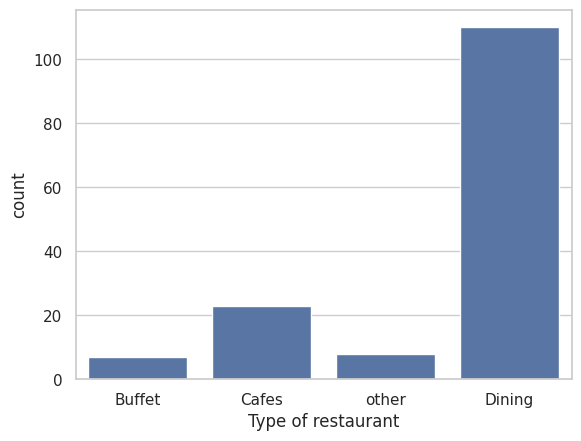

In [38]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")

**Conclusion:**

The majority of the restaurants fall into the dining category.

**2. Votes by Restaurant Type**

Here we get the count of votes for each category.

Text(0, 0.5, 'Votes')

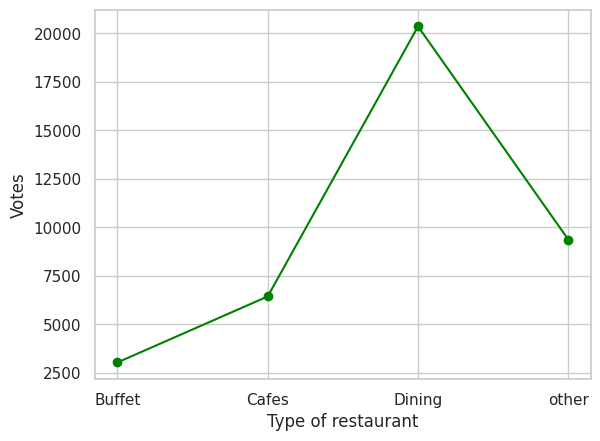

In [39]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

**Conclusion:**

Dining restaurants are preferred by a larger number of individuals.

# **Step 5: Identify the Most Voted Restaurant**

Find the restaurant with the highest number of votes.

In [40]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


# **Step 6: Online Order Availability**

Exploring the online_order column to see how many restaurants accept online orders.

<Axes: xlabel='online_order', ylabel='count'>

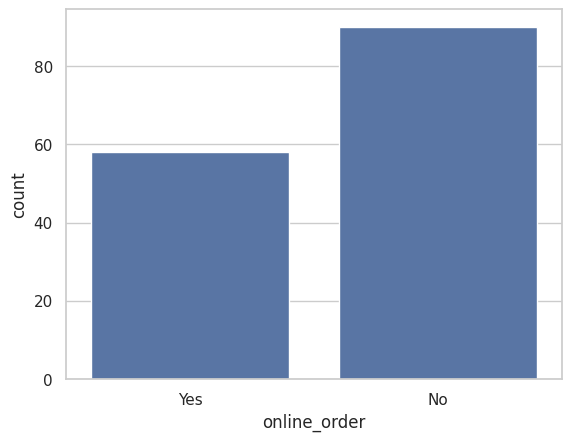

In [41]:
sns.countplot(x=dataframe['online_order'])

**Conclusion: **

This suggests that a majority of the restaurants do not accept online orders.

# **Step 7: Analyze Ratings**

Checking the distribution of ratings from the rate column.

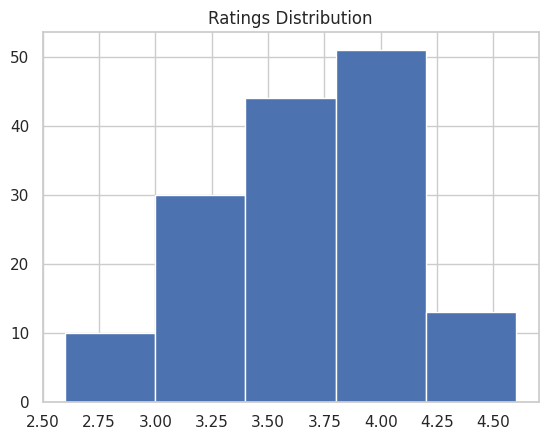

In [42]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

**Conclusion:**

The majority of restaurants received ratings ranging from 3.5 to 4.

# **Step 8: Approximate Cost for Couples**

Analyze the approx_cost(for two people) column to find the preferred price range.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

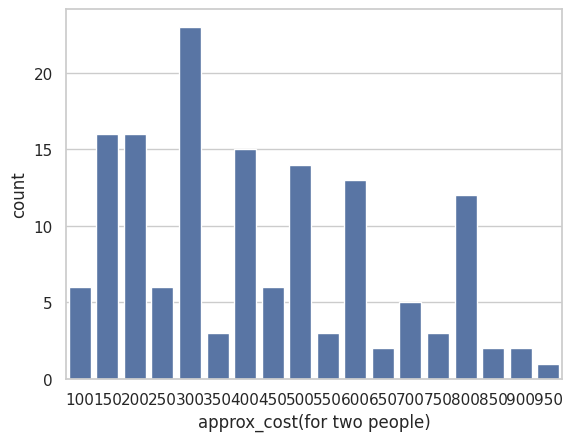

In [43]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

**Conclusion**:

The majority of restaurants received ratings ranging from 3.5 to 4.

## **Step 8: Approximate Cost for Couples**

Analyze the approx_cost(for two people) column to find the preferred price range.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

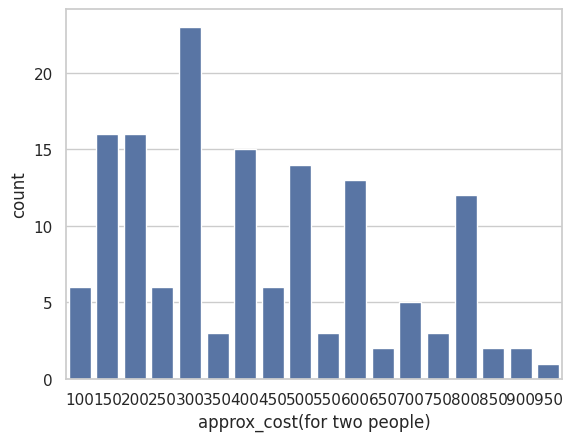

In [44]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

**Conclusion:**

The majority of couples prefer restaurants with an approximate cost of 300 rupees

# **Step 9: Ratings Comparison - Online vs Offline Orders**

Compare ratings between restaurants that accept online orders and those that don't.

<Axes: xlabel='online_order', ylabel='rate'>

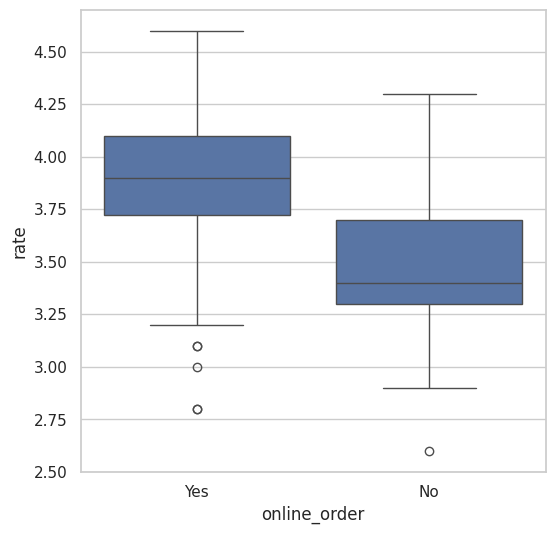

In [45]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)

**Conclusion: **

Offline orders received lower ratings in comparison to online orders which obtained excellent ratings

# **Step 10: Order Mode Preferences by Restaurant Type**

Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).

pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0): Creates a pivot table counting restaurants by type and online order availability.

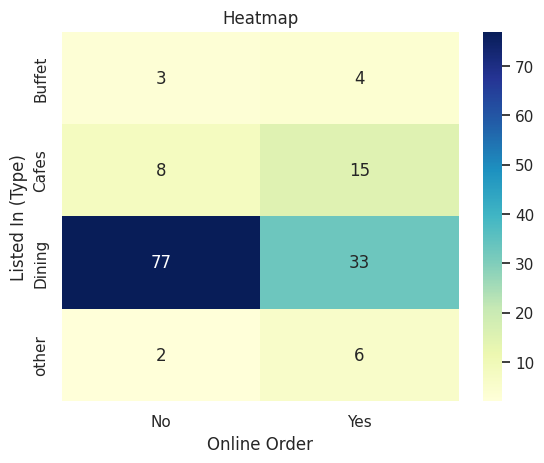

In [46]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

With this we can say that dining restaurants primarily accept offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.